In [1]:
# DTG analysis

import os
# os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import h5py
import numpy as np
import h5flow
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
# DUNE plot style
import sys, os; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [3]:
from dtg_utils import (
    thd_correct, TRAP_NAME_MAP, sum_to_traps, sum_to_tpcs,
    get_trap_indices, reject_saturation, reject_late_peaks,
    detect_pileup_find_peaks, compute_fprompt_dynamic,
    SAT_THRESHOLD, PEAK_MAX_TICK, PILEUP_MIN_DISTANCE, PILEUP_MIN_REL_HEIGHT,
    NEARLINE_DIR,
)

In [4]:
def tag_dark_counts(N_Files):

     file_num = 0
     combined_sum_wvfms = np.zeros((8,2,500), dtype=np.float64)
     #count = np.zeros((8,64))
     sipm_channels = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])
     start_value = 736
     for Nf in range(N_Files):
          file = f'/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/mpd_run_data_rctl_979_p{start_value+file_num}.FLOW.hdf5'
          if file_num < N_Files: #508:
               print('file number:', file_num)
               file_num += 1
               if not os.path.isfile(file):
                    print('File does not exist:', file)
                    continue
               else:
                    with h5py.File(file, 'r') as h5:
                         offbeam_wvfm_v1 =  h5['light/wvfm/data']['samples'][0:100,:,sipm_channels,:]
                         offbeam_wvfm_v2 =  thd_correct(offbeam_wvfm_v1)
                         
                         del offbeam_wvfm_v1
                         sum_bychan = np.sum(offbeam_wvfm_v2, axis=2)
                         # print(sum_bychan)
                         #sum_bychan = np.nan_to_num(sum_bychan, nan=0)
                         beam_start_mask = (np.mean(sum_bychan[:,7,0:50], axis=-1) < np.mean(sum_bychan[:,7,400:500], axis=-1))
                         beam_end_mask = (np.mean(sum_bychan[:,7,0:50], axis=-1) > np.mean(sum_bychan[:,7,400:500], axis=-1))
                         print('Beam Start Events:', np.sum(beam_start_mask))
                         print('Beam End Events:', np.sum(beam_end_mask))
                         print(f'Hopefully {np.sum(beam_start_mask)+np.sum(beam_end_mask)} is equal to total events: {np.shape(sum_bychan)[0]}')
                         sum_start_events = np.sum(sum_bychan[beam_start_mask==1], axis=0)
                         sum_end_events = np.sum(sum_bychan[beam_end_mask==1], axis=0)
                         normalized_start_events = (sum_start_events / np.sum(beam_start_mask))
                         normalized_end_events = (sum_end_events / np.sum(beam_end_mask))
                         print(np.shape(normalized_end_events))
                         for adc in range(8):
                              combined_sum_wvfms[adc,0,:] += normalized_start_events[adc,:]
                              combined_sum_wvfms[adc,1,:] += normalized_end_events[adc,:]
     return combined_sum_wvfms

In [5]:
average_means_evt = tag_dark_counts(5)

file number: 0


/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:199: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)


Beam Start Events: 79
Beam End Events: 21
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 1
Beam Start Events: 78
Beam End Events: 22
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 2
Beam Start Events: 78
Beam End Events: 22
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 3
Beam Start Events: 68
Beam End Events: 32
Hopefully 100 is equal to total events: 100
(8, 500)
file number: 4
Beam Start Events: 71
Beam End Events: 29
Hopefully 100 is equal to total events: 100
(8, 500)


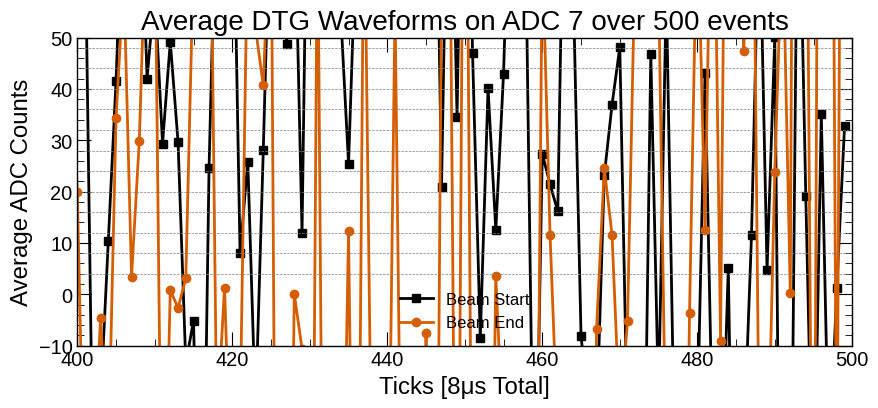

In [6]:
fig = plt.figure(figsize=(10,4))
plt.plot(np.arange(0,500,1), np.nan_to_num(average_means_evt[2,0,:], nan=0), marker='s', label='Beam Start')
#print(average_means_evt)
plt.plot(np.arange(0,500,1), np.nan_to_num(average_means_evt[2,1,:], nan=0), marker='o',label='Beam End')
# plot horizontal lines at multiples of 4
for i in range(4, 500, 4):
    plt.axhline(i, color='gray', linestyle='--', linewidth=0.5)
    

plt.title('Average DTG Waveforms on ADC 7 over 500 events')
plt.xlabel('Ticks [8μs Total]')
plt.ylabel('Average ADC Counts')
plt.ylim(-10,50)
plt.xlim(400,500)
plt.legend()
plt.show()

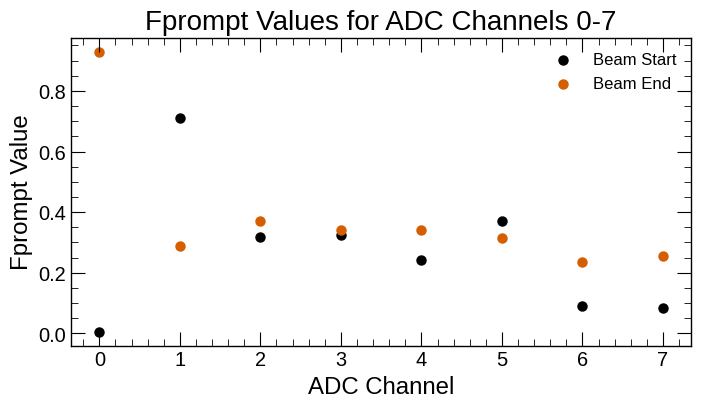

In [7]:
# calculate the fprompt for adc in range(8):
fprompt_values = np.zeros((8,2))
for adc in range(8):
     fprompt_values[adc,0] = np.sum(average_means_evt[adc,0,80:90]) / np.sum(average_means_evt[adc,0,80:500])
     fprompt_values[adc,1] = np.sum(average_means_evt[adc,1,80:90]) / np.sum(average_means_evt[adc,1,80:500])
plt.figure(figsize=(8,4))
plt.scatter(np.arange(8), fprompt_values[:,0], label='Beam Start')
plt.scatter(np.arange(8), fprompt_values[:,1], label='Beam End')
plt.xlabel('ADC Channel')
plt.ylabel('Fprompt Value')
plt.title('Fprompt Values for ADC Channels 0-7')
plt.xticks(np.arange(8))
plt.legend()
plt.show()

Global max raw ADC value : 32764
Global min raw ADC value : -32116
99th percentile per-event max: 32764
Events at global max         : 6042


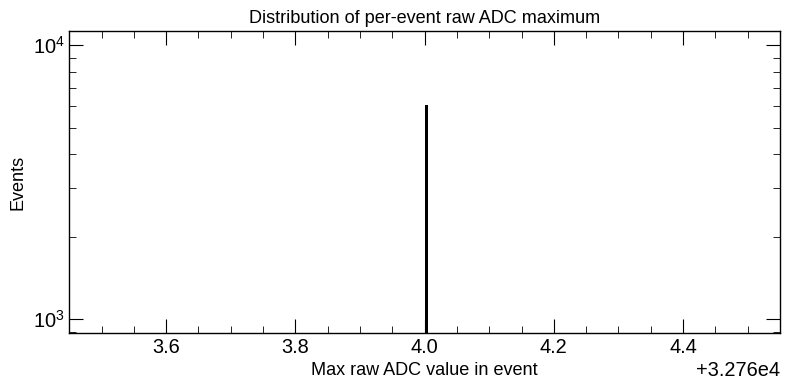

In [8]:
# Quick check: what is the actual ADC saturation value?
# Opens one file, reads raw samples, prints the maximum and plots its distribution.

check_file = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/mpd_run_data_rctl_978_p19.FLOW.hdf5'
_f = h5flow.data.H5FlowDataManager(check_file, mode="r")
try:
    raw_check = _f['/light/wvfm/data']['samples'][:, :, :, :500]
finally:
    _f.finish()

event_max = raw_check.reshape(len(raw_check), -1).max(axis=-1)  # one value per event

print(f"Global max raw ADC value : {raw_check.max()}")
print(f"Global min raw ADC value : {raw_check.min()}")
print(f"99th percentile per-event max: {np.percentile(event_max, 99):.0f}")
print(f"Events at global max         : {(raw_check == raw_check.max()).any(axis=(-1,-2,-3)).sum()}")

plt.figure(figsize=(8, 4))
plt.hist(event_max, bins=200)
plt.xlabel("Max raw ADC value in event", fontsize=13)
plt.ylabel("Events", fontsize=13)
plt.title("Distribution of per-event raw ADC maximum", fontsize=13)
plt.yscale("log")
plt.minorticks_on()
plt.tick_params(direction="in", which="both")
plt.tight_layout()
plt.show()
del raw_check


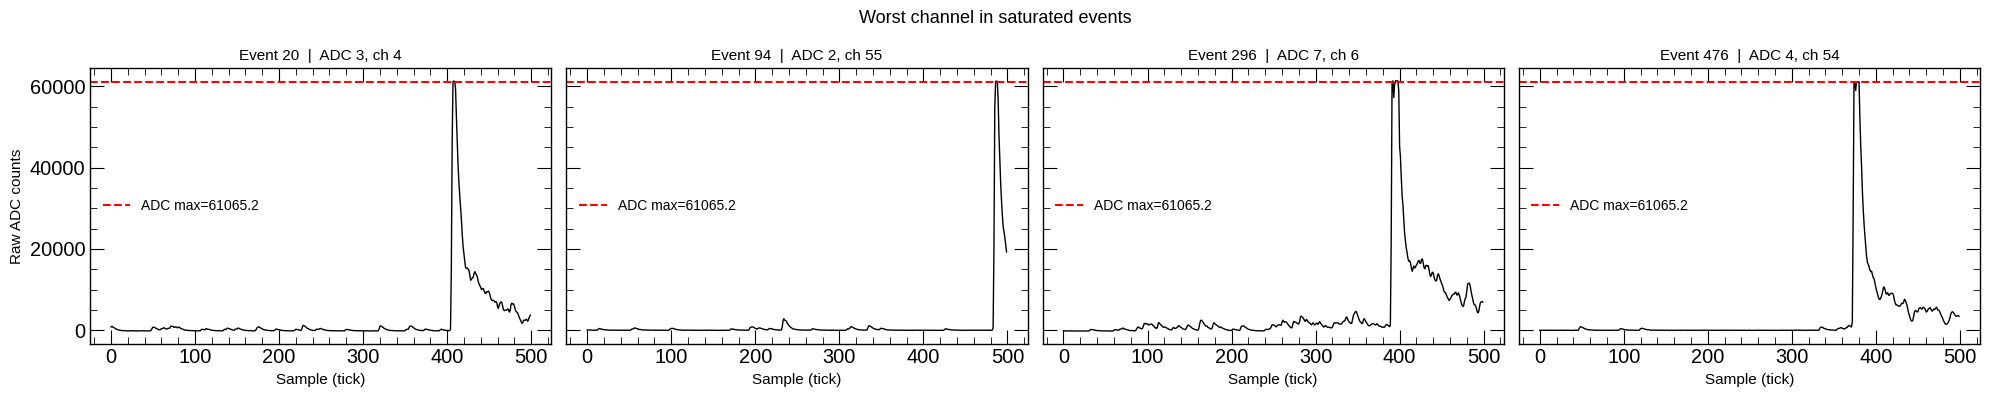

Total saturated events : 40 / 6042


In [9]:
# Inspect actual waveforms to confirm saturation visually.
# Re-loads the file (raw_check was deleted above to save memory).

_f = h5flow.data.H5FlowDataManager(check_file, mode="r")
try:
    raw_check = _f['/light/wvfm/data']['samples'][:, :, :, :500]
finally:
    _f.finish()

raw_check = thd_correct(raw_check)
sat_val = raw_check.max() - 500

# Find which events contain at least one saturated sample
sat_events = np.where(
    (raw_check >= sat_val).any(axis=(-1, -2, -3))
)[0]

# For each of the first 4 saturated events: find the worst ADC+channel and plot it
n_show = 4#min(4, len(sat_events))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4), sharey=True)
if n_show == 1:
    axes = [axes]

for ax, ev_idx in zip(axes, sat_events[:n_show]):
    wvfm = raw_check[ev_idx]          # shape: (n_adc, n_chan, n_samp)
    # Find the ADC+channel with the highest peak
    ch_max = wvfm.reshape(-1, wvfm.shape[-1]).max(axis=-1).argmax()
    adc_i, ch_i = divmod(ch_max, wvfm.shape[1])
    trace = wvfm[adc_i, ch_i]

    ax.plot(trace, lw=1)
    ax.axhline(sat_val, color="red", lw=1.5, ls="--", label=f"ADC max={sat_val}")
    ax.set_title(f"Event {ev_idx}  |  ADC {adc_i}, ch {ch_i}", fontsize=11)
    ax.set_xlabel("Sample (tick)", fontsize=11)
    ax.legend(fontsize=10)

axes[0].set_ylabel("Raw ADC counts", fontsize=11)
plt.suptitle("Worst channel in saturated events", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total saturated events : {len(sat_events)} / {len(raw_check)}")
del raw_check


In [10]:
h5flow.data.H5FlowDataManager(check_file, mode="r")['light/events/data'].dtype.names

('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid', 'trig_type')

In [ ]:
# Light trap map, aggregation functions, and detector indices are now in dtg_utils.
# TRAP_NAME_MAP, sum_to_traps, sum_to_tpcs imported in the cell above.

acl_idx, acl_tpc = get_trap_indices("acl")
lcm_idx, lcm_tpc = get_trap_indices("lcm")
print(f"ACL traps (excl. TPC 6): {len(acl_idx)},  LCM traps (excl. TPC 6): {len(lcm_idx)}")

ACL traps (excl. TPC 6): 28,  LCM traps (excl. TPC 6): 28


: 

In [ ]:
def find_valid_triggers(samples):
    pmt_wvfm_v2 = samples[:, :]*(-0.25) # The PMT pulse has negative polarity

    noise_sum_all = np.sum(pmt_wvfm_v2[:,5:100], axis=-1)
    noise_sum_fast = np.sum(pmt_wvfm_v2[:,5:18], axis=-1)

    fast_light = np.sum(pmt_wvfm_v2[:,105:118], axis=-1) - noise_sum_fast
    all_light = np.sum(pmt_wvfm_v2[:,105:200], axis=-1) - noise_sum_all
    ratio = fast_light / all_light

    fprompt_mask = (ratio > 0.001) & (ratio < 0.2)
    thd_mask = (pmt_wvfm_v2[:,100:300] > 70)
    pick_out_low = (np.sum(thd_mask[:,5:120], axis=-1) <= 15)
    return fprompt_mask & (~pick_out_low)


def extract_time(x):
    if "no_source" in x:
        return -1
    return int(x.split("/")[-4][9:12].replace("u", "").replace("r_", ""))


from scipy.signal import find_peaks

records = []

max_files           = 15
max_events_per_file = 5000

source_folder = NEARLINE_DIR

source_files = [os.path.join(source_folder, f)
                for f in os.listdir(source_folder) if f.endswith(".hdf5")]

for path in source_files[:max_files]:
    print(f"Processing: {os.path.basename(path)}")
    f = h5flow.data.H5FlowDataManager(path, mode="r")
    try:
        raw = f['/light/wvfm/data']["samples"][:max_events_per_file, :, :, :500]
    finally:
        f.finish()

    samples    = thd_correct(raw);  del raw
    saturated  = reject_saturation(samples, SAT_THRESHOLD)
    trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP);  del samples
    n_ev = len(trap_wvfms)

    late_peak = reject_late_peaks(trap_wvfms, PEAK_MAX_TICK)
    bad_event = saturated | late_peak

    print(f"  Saturated      : {saturated.sum()} / {n_ev}")
    print(f"  Late peak      : {late_peak.sum()} / {n_ev}")
    print(f"  Total rejected : {bad_event.sum()} / {n_ev}")

    trap_fprompts, trap_integrals, _ = compute_fprompt_dynamic(trap_wvfms)
    n_peaks_traps = detect_pileup_find_peaks(trap_wvfms, PILEUP_MIN_DISTANCE, PILEUP_MIN_REL_HEIGHT)

    pileup_acl = (n_peaks_traps[:, acl_idx] > 1).any(axis=1)
    pileup_lcm = (n_peaks_traps[:, lcm_idx] > 1).any(axis=1)
    print(f"  Pileup in any ACL trap: {pileup_acl.sum()} / {n_ev}  (flagged in records)")
    print(f"  Pileup in any LCM trap: {pileup_lcm.sum()} / {n_ev}  (flagged in records)")

    records.extend(
        {
            "file":           path,
            "delay":          extract_time(path),
            "fprompt_acl":    trap_fprompts[i, acl_idx],
            "energy_acl":     trap_integrals[i, acl_idx],
            "n_peaks_acl":    n_peaks_traps[i, acl_idx],
            "fprompt_lcm":    trap_fprompts[i, lcm_idx],
            "energy_lcm":     trap_integrals[i, lcm_idx],
            "n_peaks_lcm":    n_peaks_traps[i, lcm_idx],
            "R":              "R1",
            "valid_event":    i,
        }
        for i in range(0, n_ev, 2)
        if not bad_event[i]
    )
    records.extend(
        {
            "file":           path,
            "delay":          extract_time(path),
            "fprompt_acl":    trap_fprompts[i + 1, acl_idx],
            "energy_acl":     trap_integrals[i + 1, acl_idx],
            "n_peaks_acl":    n_peaks_traps[i + 1, acl_idx],
            "fprompt_lcm":    trap_fprompts[i + 1, lcm_idx],
            "energy_lcm":     trap_integrals[i + 1, lcm_idx],
            "n_peaks_lcm":    n_peaks_traps[i + 1, lcm_idx],
            "R":              "R2",
            "valid_event":    i + 1,
        }
        for i in range(0, n_ev, 2)
        if i + 1 < n_ev and not bad_event[i + 1]
    )

Processing: mpd_run_data_rctl_979_p516.FLOW.hdf5


/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:199: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)


  Saturated      : 91 / 2919
  Late peak      : 5 / 2919
  Total rejected : 96 / 2919


/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:301: RuntimeWarning: divide by zero encountered in divide
  fprompt = fprompt_num / fprompt_den


  Pileup in any ACL trap: 2919 / 2919  (flagged in records)
  Pileup in any LCM trap: 2919 / 2919  (flagged in records)
Processing: mpd_run_data_rctl_979_p419.FLOW.hdf5
  Saturated      : 102 / 3051
  Late peak      : 4 / 3051
  Total rejected : 106 / 3051
  Pileup in any ACL trap: 3051 / 3051  (flagged in records)
  Pileup in any LCM trap: 3051 / 3051  (flagged in records)
Processing: mpd_run_data_rctl_978_p19.FLOW.hdf5


In [ ]:
# ── Timestamp diagnostic ──────────────────────────────────────────────────────
# Check whether the HDF5 files contain a wall-clock timestamp we can use to
# place each file on the Ar-41 decay curve.

import h5py, datetime

_check = source_files[0]
with h5py.File(_check, "r") as _h:
    def _print_tree(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name:50s}  shape={obj.shape}  dtype={obj.dtype}")
    print("=== HDF5 structure ===")
    _h.visititems(_print_tree)

    # Common timestamp locations — print whatever looks like a time
    for candidate in ["/light/events/data", "/light/wvfm/data",
                      "/charge/events/data", "/"]:
        try:
            ds = _h[candidate]
            if hasattr(ds, "dtype") and ds.dtype.names:
                print(f"\nFields in {candidate}: {ds.dtype.names}")
            elif hasattr(ds, "attrs"):
                print(f"\nAttrs of {candidate}: {dict(ds.attrs)}")
        except Exception:
            pass


=== HDF5 structure ===
  light/events/data                                   shape=(2919,)  dtype=[('id', '<u8'), ('event', '<i4'), ('sn', '<i4', (8,)), ('utime_ms', '<u8', (8,)), ('tai_ns', '<u8', (8,)), ('wvfm_valid', 'u1', (8, 64)), ('trig_type', 'u1')]
  light/events/ref/light/wvfm/ref                     shape=(2919, 2)  dtype=uint32
  light/events/ref/light/wvfm/ref_region              shape=(2919,)  dtype=[('start', '<i4'), ('stop', '<i4')]
  light/wvfm/data                                     shape=(2919,)  dtype=[('samples', '<i2', (8, 64, 500))]
  light/wvfm/ref/light/events/ref_region              shape=(2919,)  dtype=[('start', '<i4'), ('stop', '<i4')]

Fields in /light/events/data: ('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid', 'trig_type')

Fields in /light/wvfm/data: ('samples',)

Attrs of /: {}


In [ ]:
import pandas as pd
df = pd.DataFrame(records)

In [ ]:
df.head()

,file,delay,fprompt_acl,energy_acl,n_peaks_acl,fprompt_lcm,energy_lcm,n_peaks_lcm,R,valid_event
0,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[-0.022106360792485794, -0.012686815011625741,...","[-128.00000000189175, -6019.999999999418, -324...","[3, 3, 5, 4, 4, 3, 4, 4, 4, 4, 5, 5, 5, 4, 4, ...","[-0.20059880239520958, 0.9223076923074077, 0.0...","[616.0, 1248.0000000004366, 144.0, -1935.99999...","[4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 1, 4, 3, 5, 4, ...",R1,0
1,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[-0.05419580419580419, -0.7753086419746976, 0....","[-1912.0, -1888.000000000582, -7615.9999999998...","[3, 3, 3, 4, 3, 4, 4, 4, 3, 4, 3, 4, 5, 5, 4, ...","[-0.016780821917809236, -0.0374603174603324, 0...","[3212.000000000291, -107.99999999832653, -343....","[4, 4, 5, 3, 4, 4, 5, 5, 4, 4, 4, 3, 1, 1, 4, ...",R1,2
2,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[0.325342465753643, 0.044216585716855834, 0.32...","[2903.9999999974534, -2512.0000000005093, 3451...","[3, 5, 4, 3, 4, 4, 4, 4, 3, 4, 4, 3, 3, 3, 4, ...","[0.08206521739130952, 0.0073684210526471184, -...","[-3619.999999997308, 351.99999999934516, -68.0...","[3, 5, 5, 4, 4, 4, 4, 5, 4, 5, 5, 4, 3, 5, 4, ...",R1,4
3,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[0.85, 0.15356037151701193, -0.709917355372184...","[-1872.0, -3876.000000000655, -215.99999999956...","[4, 5, 4, 4, 4, 4, 4, 4, 1, 5, 1, 1, 5, 4, 5, ...","[0.055821271239769314, -0.14891304347833614, 0...","[-2355.9999999965803, -4247.999999998763, -307...","[3, 4, 4, 3, 4, 3, 4, 4, 1, 1, 1, 1, 5, 3, 4, ...",R1,6
4,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,40,"[-0.9723577235781031, 0.5773333333340886, 0.17...","[1528.0000000010186, 1959.9999999977445, -4144...","[4, 3, 5, 4, 5, 4, 4, 4, 4, 4, 3, 4, 4, 1, 1, ...","[0.43899371069137416, -2.953571428597399, -0.0...","[-332.0000000019645, 1847.999999997599, -4559....","[4, 4, 4, 3, 5, 4, 4, 5, 5, 5, 3, 3, 4, 1, 1, ...",R1,8


In [ ]:
# plot the distribution of n_peaks for valid events
# plt.figure(figsize=(8, 4))
# plt.hist(df["n_peaks"], bins=np.arange(0, df["n_peaks"].max() + 1) - 0.5, density=True)
# plt.xlabel("Number of peaks in total waveform", fontsize=13)
# plt.ylabel("Fraction of valid events", fontsize=13)
# plt.title("Distribution of pileup in valid events", fontsize=13)
# plt.yscale("log")
# plt.minorticks_on()
# plt.tick_params(direction="in", which="both")
# plt.tight_layout()
# plt.show()

In [ ]:
bins = np.arange(0, 1.1, 0.02)

In [ ]:
# # Plot fprompt distribution for the background events and source events
# plt.figure(figsize=(10, 6))
# # plt.hist(df[df["delay"] == -1]["fprompt"], bins=bins, alpha=0.5, label="Background", color="blue")
# # Only R1
# plt.hist(df[(df["delay"] != -1) & (df["R"] == "R1")]["fprompt"], bins=bins, alpha=0.5, label="Source prompt window")
# # Only R2
# plt.hist(df[(df["delay"] != -1) & (df["R"] == "R2")]["fprompt"], bins=bins, alpha=0.5, label="Source delayed window")
# plt.xlabel("Fprompt")
# plt.ylabel("Count")
# plt.xlim(0,1)
# plt.legend()
# plt.show()

In [ ]:
# get a long flat list of fprompts and corresponding energies for all events
# df1 = df
# fprompts = df1["fprompt"].values
# energies = df1["energy"].values

# flat_fprompts = []
# flat_energies = []
# for sub in fprompts:
#     flat_fprompts.extend(sub.flatten())
# for sub in energies:
#     flat_energies.extend(sub.flatten())

In [ ]:
# replace NaN values in fprompts with 0
# flat_fprompts = np.nan_to_num(flat_fprompts, nan=0)
# flat_energies = np.nan_to_num(flat_energies, nan=0)
# plt.hist2d(flat_energies, flat_fprompts, bins=[15000, bins], norm=LogNorm())
# plt.xlabel("Integral (ADC counts*tick)")
# plt.ylabel("Fprompt")
# plt.xlim(0, 1e7)
# plt.show()

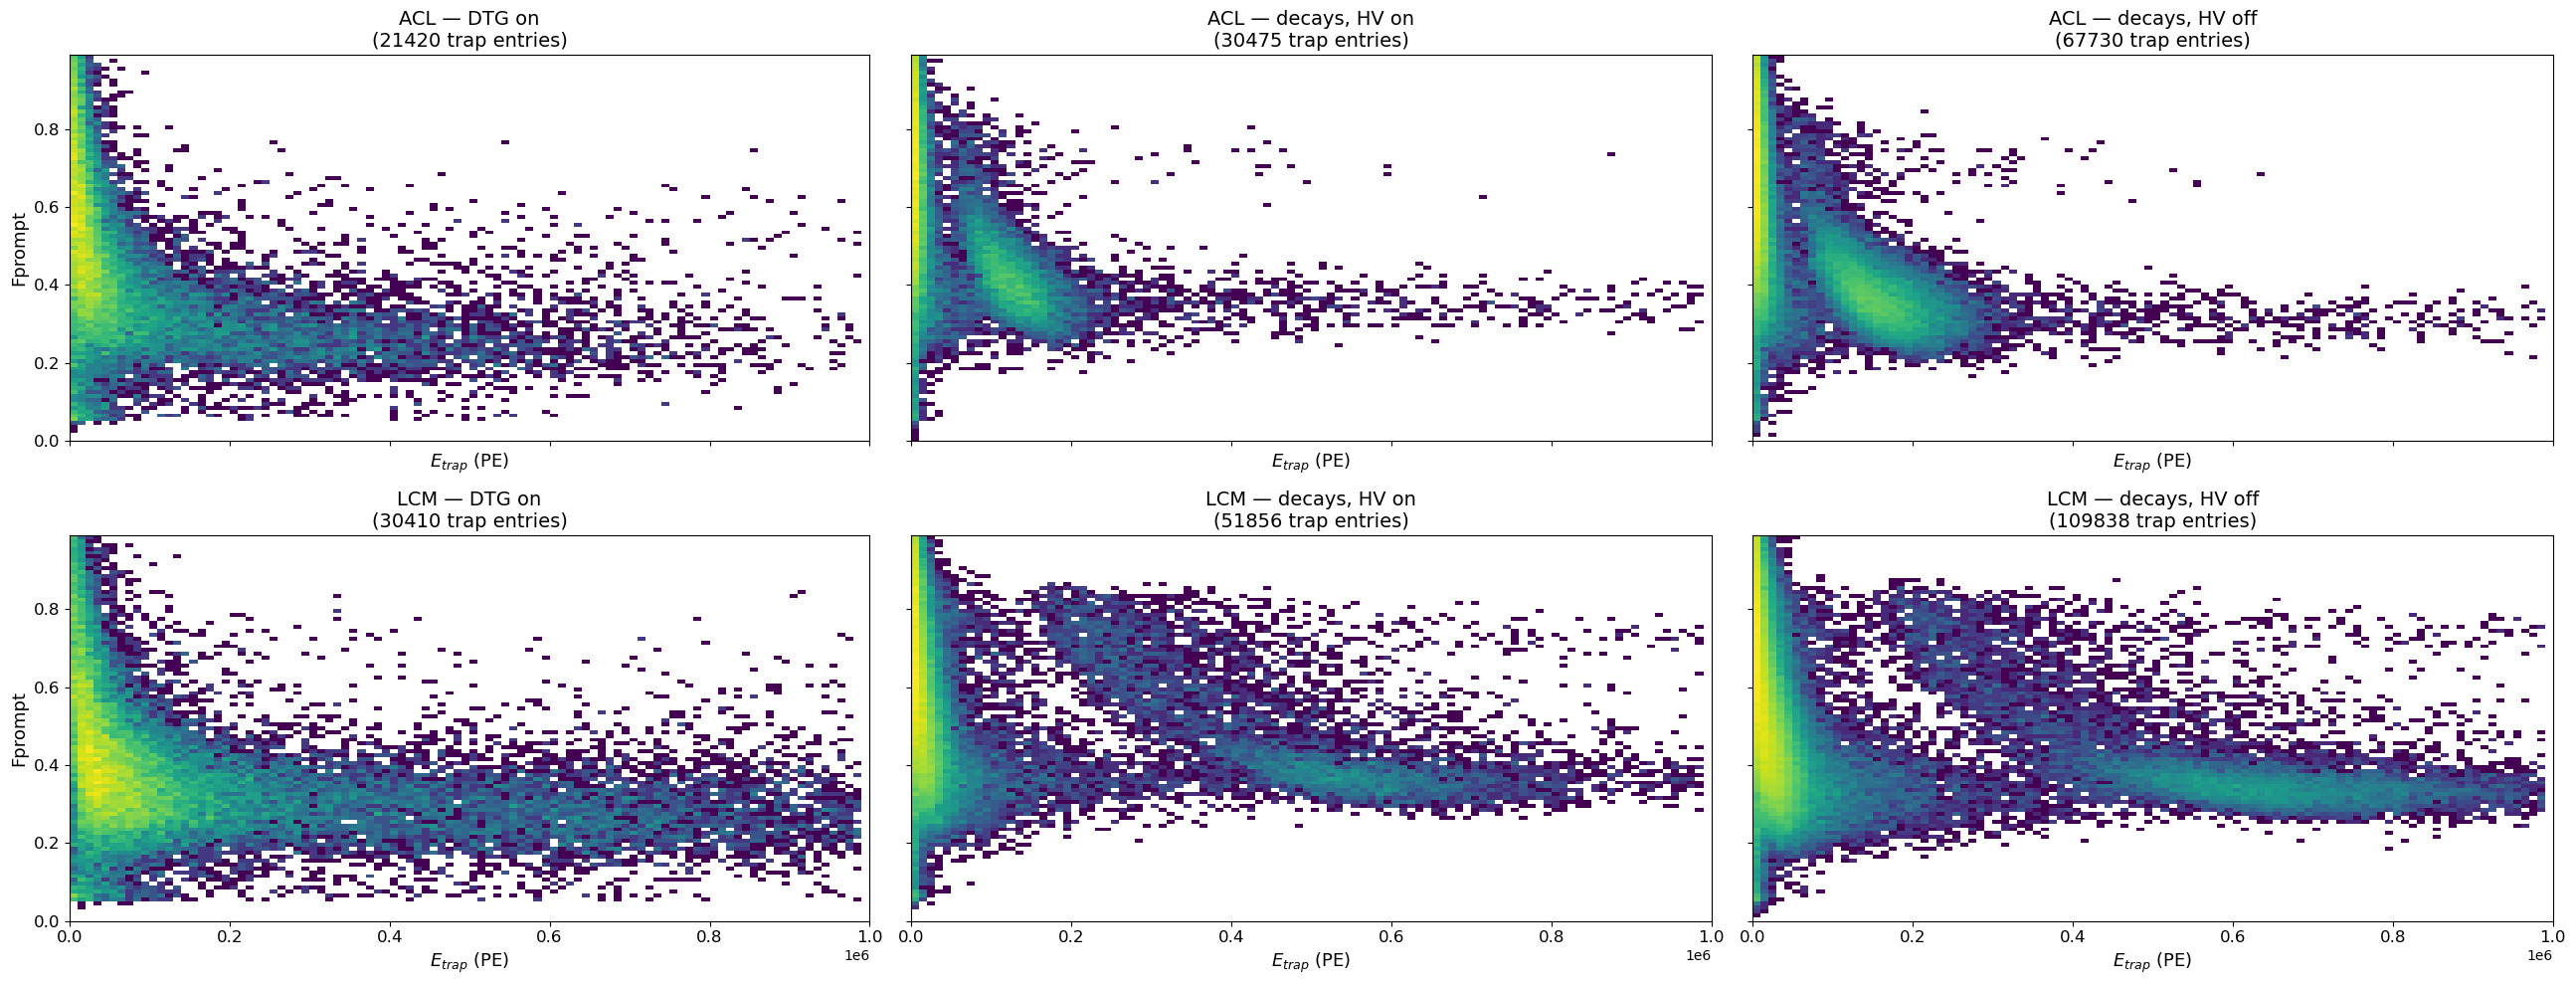

In [ ]:
conditions = {
    "978": "DTG on",
    "979": "decays, HV on",
    "980": "decays, HV off",
}

detector_types = [
    ("fprompt_acl", "energy_acl", "n_peaks_acl", "ACL"),
    ("fprompt_lcm", "energy_lcm", "n_peaks_lcm", "LCM"),
]

fig, axes = plt.subplots(2, 3, figsize=(26, 10), sharey=True, sharex=True)

for row, (fp_col, en_col, np_col, det_label) in enumerate(detector_types):
    col = 0
    for key, cond_label in conditions.items():
        subset = df[df["file"].str.contains(key)]
        if len(subset) == 0:
            col += 1
            continue

        # Flatten all trap entries across all events, then mask per-trap pileup
        flat_fp  = np.concatenate(subset[fp_col].values)
        flat_en  = np.concatenate(subset[en_col].values)
        flat_np  = np.concatenate(subset[np_col].values)

        # Keep only trap entries that have exactly one peak (no pileup)
        clean = (flat_np == 1) & np.isfinite(flat_fp) & np.isfinite(flat_en)
        flat_fp = flat_fp[clean]
        flat_en = flat_en[clean]

        axes[row, col].hist2d(
            flat_en,
            flat_fp,
            bins=[np.arange(0, 1e6, 1e4), np.arange(0, 1, 0.01)],
            norm=LogNorm(),
        )
        axes[row, col].set_title(f"{det_label} — {cond_label}\n({clean.sum()} trap entries)", fontsize=14)
        axes[row, col].set_xlabel("$E_{trap}$ (PE)", fontsize=13)
        axes[row, col].tick_params(axis="both", which="major", labelsize=12)
        col += 1

    axes[row, 0].set_ylabel("Fprompt", fontsize=13)

plt.xlim(0, 1e6)
plt.tight_layout()
plt.show()


In [68]:
# ── fprompt vs PE for DTG-on data (memory-safe, with sat/pileup overlays) ─────
import h5py, numpy as np, matplotlib.pyplot as plt, os
from scipy.signal import find_peaks
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

from dtg_utils import (
    thd_correct, TRAP_NAME_MAP, sum_to_traps,
    get_trap_indices, compute_fprompt_dynamic,
    NEARLINE_DIR,
)

acl_idx, acl_tpc = get_trap_indices("acl")
lcm_idx, lcm_tpc = get_trap_indices("lcm")

DETECTOR = "acl"       # "lcm" or "acl"
TPC_FILTER = None       # None = all TPCs, or int
N_FILES = 15             # keep small — DTG-on has very high rate
CHUNK = 200             # events per chunk to avoid OOM

MIN_HEIGHT = 1000        # minimum peak amplitude (ADC counts, trap sum)
LATE_TICK = 300         # reject peaks after this tick
PEAK_DISTANCE = 50      # min tick separation for pileup find_peaks
SAT_RAW = 32750         # raw ADC saturation threshold (before baseline correction)

# Pick DTG-on files (rctl_978 = DTG on)
dtg_on_files = sorted(
    os.path.join(NEARLINE_DIR, f)
    for f in os.listdir(NEARLINE_DIR)
    if f.endswith(".hdf5") and "978" in f
)[:N_FILES]
print(f"Processing {len(dtg_on_files)} DTG-on files")

det_idx = acl_idx if DETECTOR == "acl" else lcm_idx
det_tpc = acl_tpc if DETECTOR == "acl" else lcm_tpc
n_det = len(det_idx)

fp_clean, en_clean = [], []
fp_sat, en_sat = [], []
fp_pileup, en_pileup = [], []
livetime_s = 0.0

for fi, path in enumerate(dtg_on_files):
    with h5py.File(path, "r") as h:
        utime_ms = h["light/events/data"]["utime_ms"]
        n_total = len(utime_ms)
        if n_total >= 2:
            livetime_s += (float(utime_ms[-1][0]) - float(utime_ms[0][0])) / 1e3
        wvfm_ds = h["/light/wvfm/data"]["samples"]

        for start in range(0, n_total, CHUNK):
            stop = min(start + CHUNK, n_total)
            raw = wvfm_ds[start:stop, :, :, :500]
            n_ev = len(raw)

            # 1. Per-trap saturation on RAW data (before baseline correction)
            sat_det = np.zeros((n_ev, n_det), dtype=bool)
            for j, ti in enumerate(det_idx):
                entry = TRAP_NAME_MAP[ti]
                ch_raw = raw[:, entry["adc"], entry["channels"], :]
                sat_det[:, j] = (ch_raw >= SAT_RAW).any(axis=(1, 2))

            # 2. Baseline correct, sum to traps
            samples = thd_correct(raw.astype(np.float32)); del raw
            trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples

            # 3. Dynamic fprompt (peak found per trap via argmax)
            trap_fp, trap_int, peak_idx = compute_fprompt_dynamic(trap_wvfms)

            # 4. Select detector columns
            fp_det = trap_fp[:, det_idx]
            en_det = trap_int[:, det_idx]
            pk_det = peak_idx[:, det_idx]
            amp_det = trap_wvfms[:, det_idx, :].max(axis=-1)

            # 5. Pileup via find_peaks (detector traps only)
            det_wvfms = trap_wvfms[:, det_idx, :]
            np_det = np.zeros((n_ev, n_det), dtype=np.int8)
            for ev_i in range(n_ev):
                for j in range(n_det):
                    pks, _ = find_peaks(det_wvfms[ev_i, j],
                                        height=MIN_HEIGHT, distance=PEAK_DISTANCE)
                    np_det[ev_i, j] = np.sum(pks <= LATE_TICK)
            del trap_wvfms, det_wvfms

            if TPC_FILTER is not None:
                col = det_tpc == TPC_FILTER
                fp_det  = fp_det[:, col]
                en_det  = en_det[:, col]
                pk_det  = pk_det[:, col]
                amp_det = amp_det[:, col]
                np_det  = np_det[:, col]
                sat_det = sat_det[:, col]

            fp_flat  = fp_det.ravel()
            en_flat  = en_det.ravel()
            pk_flat  = pk_det.ravel()
            amp_flat = amp_det.ravel()
            np_flat  = np_det.ravel()
            sat_flat = sat_det.ravel()

            # Quality cuts: finite, peak before LATE_TICK, amplitude >= MIN_HEIGHT
            valid = (np.isfinite(fp_flat) & np.isfinite(en_flat)
                     & (pk_flat <= LATE_TICK) & (amp_flat >= MIN_HEIGHT))

            m_clean  = valid & ~sat_flat & (np_flat == 1)
            m_sat    = valid & sat_flat
            m_pileup = valid & ~sat_flat & (np_flat > 1)

            fp_clean.append(fp_flat[m_clean]);   en_clean.append(en_flat[m_clean])
            fp_sat.append(fp_flat[m_sat]);       en_sat.append(en_flat[m_sat])
            fp_pileup.append(fp_flat[m_pileup]); en_pileup.append(en_flat[m_pileup])

    print(f"  [{fi+1}/{len(dtg_on_files)}] {os.path.basename(path)}: {n_total} events")

fp_clean  = np.concatenate(fp_clean);  en_clean  = np.concatenate(en_clean)
fp_sat    = np.concatenate(fp_sat);    en_sat    = np.concatenate(en_sat)
fp_pileup = np.concatenate(fp_pileup); en_pileup = np.concatenate(en_pileup)

print(f"\nLivetime: {livetime_s:.1f} s")
print(f"Clean: {len(fp_clean):,}  Saturated: {len(fp_sat):,}  Pileup: {len(fp_pileup):,}")

Processing 15 DTG-on files
  [1/15] mpd_run_data_rctl_978_p0.FLOW.hdf5: 2801 events
  [2/15] mpd_run_data_rctl_978_p1.FLOW.hdf5: 6043 events
  [3/15] mpd_run_data_rctl_978_p10.FLOW.hdf5: 6036 events
  [4/15] mpd_run_data_rctl_978_p11.FLOW.hdf5: 6045 events
  [5/15] mpd_run_data_rctl_978_p12.FLOW.hdf5: 6041 events
  [6/15] mpd_run_data_rctl_978_p13.FLOW.hdf5: 6033 events
  [7/15] mpd_run_data_rctl_978_p14.FLOW.hdf5: 6045 events
  [8/15] mpd_run_data_rctl_978_p15.FLOW.hdf5: 6043 events
  [9/15] mpd_run_data_rctl_978_p16.FLOW.hdf5: 6036 events
  [10/15] mpd_run_data_rctl_978_p17.FLOW.hdf5: 6037 events
  [11/15] mpd_run_data_rctl_978_p18.FLOW.hdf5: 6025 events
  [12/15] mpd_run_data_rctl_978_p19.FLOW.hdf5: 6042 events
  [13/15] mpd_run_data_rctl_978_p2.FLOW.hdf5: 6039 events
  [14/15] mpd_run_data_rctl_978_p20.FLOW.hdf5: 6043 events
  [15/15] mpd_run_data_rctl_978_p21.FLOW.hdf5: 6045 events

Livetime: 436.2 s
Clean: 211,391  Saturated: 32,224  Pileup: 323,766


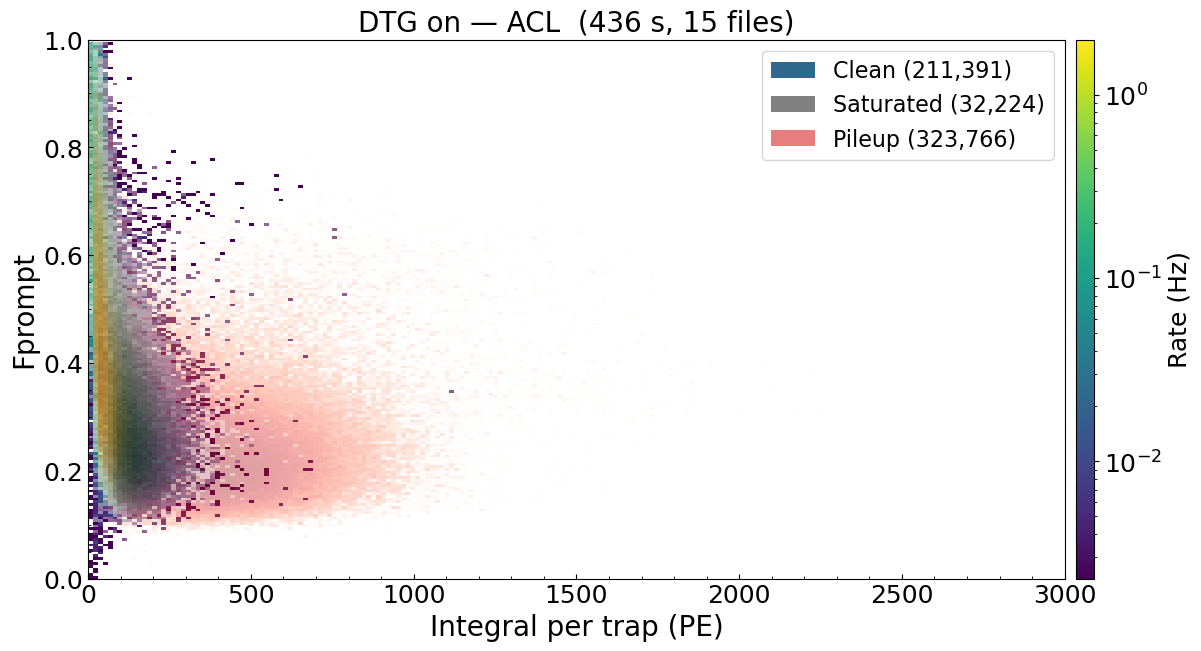

In [73]:

# ── Plot ─────────────────────────────────────────────────────────────
en_conv = lambda e: e * 0.004 / 4  # to PE if needed — adjust or remove

nbins = 200
xe = np.arange(0, 5000, 15)
ye = np.arange(0, 1, 0.005)

fig, ax = plt.subplots(figsize=(15, 7))

# Clean events — rate
im = None
if len(en_clean) > 0:
    h, _, _ = np.histogram2d(en_conv(en_clean), fp_clean, bins=[xe, ye])
    rate_h = np.ma.masked_where(h == 0, h / livetime_s)
    im = ax.pcolormesh(xe, ye, rate_h.T, norm=LogNorm(), cmap='viridis', rasterized=True)



# # # Pileup in red
if len(en_pileup) > 0:
    h, _, _ = np.histogram2d(en_conv(en_pileup), fp_pileup, bins=[xe, ye])
    r = np.ma.masked_where(h == 0, h / livetime_s)
    ax.pcolormesh(xe, ye, r.T, norm=LogNorm(), cmap='Reds', alpha=0.4, rasterized=True)

# # # Saturated in gray
if len(en_sat) > 0:
    h, _, _ = np.histogram2d(en_conv(en_sat), fp_sat, bins=[xe, ye])
    r = np.ma.masked_where(h == 0, h / livetime_s)
    ax.pcolormesh(xe, ye, r.T, norm=LogNorm(), cmap='Greys', alpha=0.4, rasterized=True)

if im is not None:
    cb = fig.colorbar(im, ax=ax, pad=0.01, aspect=30)
    cb.set_label("Rate (Hz)", fontsize=18)
    for t in cb.ax.get_yticklabels():
        t.set_fontsize(18)

tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
ax.set_title(f"DTG on — {DETECTOR.upper()}{tpc_label}  ({livetime_s:.0f} s, {N_FILES} files)", fontsize=20)
ax.set_xlabel("Integral per trap (PE)", fontsize=20)
ax.set_ylabel("Fprompt", fontsize=20)
ax.set_xlim(0, 3000)
ax.set_ylim(0, 1)
ax.tick_params(labelsize=18, direction="in", which="both")
ax.minorticks_on()

legend_handles = [
    Patch(facecolor='#31688e', label=f'Clean ({len(fp_clean):,})'),
    Patch(facecolor='gray',    label=f'Saturated ({len(fp_sat):,})'),
    Patch(facecolor='#d62728', alpha=0.6, label=f'Pileup ({len(fp_pileup):,})'),
]
ax.legend(handles=legend_handles, fontsize=16, loc="upper right")

# plt.tight_layout()
plt.show()

Trap peak amplitude: median=171, 95th=532, max=9124
Traps with peak > 1200 AND before tick 300: 153 / 64000
Saturated traps: 1000 / 64000

Clean:     ev 156, trap 26 (amp=7935)
Saturated: ev 664, trap 55 (amp=1549)
Pileup:    ev 33, trap 60 (2 peaks)


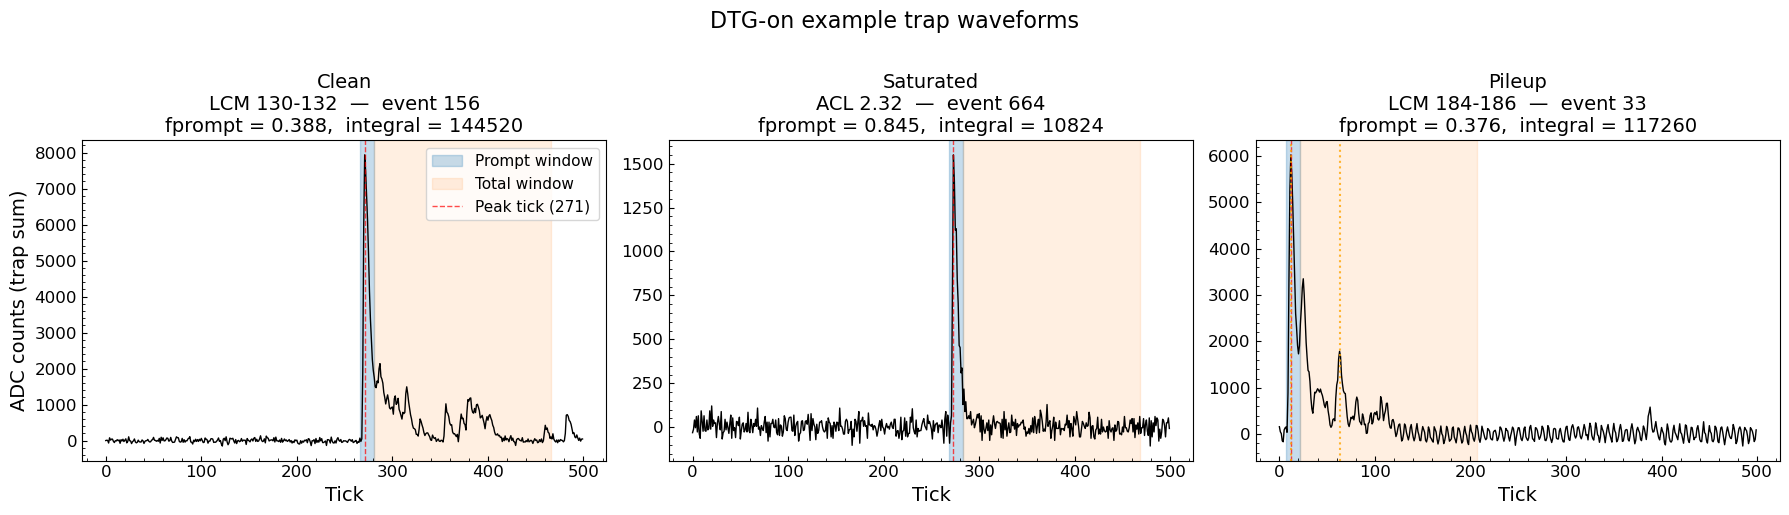

In [57]:
# ── Example waveforms: clean, saturated, pileup ─────────────────────────────
import h5py, numpy as np, matplotlib.pyplot as plt, os
from scipy.signal import find_peaks
from dtg_utils import thd_correct, TRAP_NAME_MAP, sum_to_traps, NEARLINE_DIR

dtg_file = sorted(
    os.path.join(NEARLINE_DIR, f)
    for f in os.listdir(NEARLINE_DIR)
    if f.endswith(".hdf5") and "978" in f
)[0]

N_EV = 1000
MIN_HEIGHT = 1200        # minimum peak amplitude (ADC counts, trap sum)
LATE_TICK = 300          # reject peaks after this tick
PEAK_DISTANCE = 50       # min tick separation between peaks
SAT_RAW = 32750          # raw ADC saturation threshold (before baseline correction)

with h5py.File(dtg_file, "r") as h:
    raw = h["/light/wvfm/data"]["samples"][:N_EV, :, :, :500]

# 1. Per-trap saturation on RAW data (before baseline correction)
n_traps = len(TRAP_NAME_MAP)
sat_per_trap = np.zeros((N_EV, n_traps), dtype=bool)
for i, entry in enumerate(TRAP_NAME_MAP):
    ch_raw = raw[:, entry["adc"], entry["channels"], :]  # (N_EV, 6, 500)
    sat_per_trap[:, i] = (ch_raw >= SAT_RAW).any(axis=(1, 2))

# 2. Baseline correct, sum to traps
samples = thd_correct(raw.astype(np.float32)); del raw
trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples

# --- Diagnostics ---
peak_amps = trap_wvfms.max(axis=-1)
peak_ticks = trap_wvfms.argmax(axis=-1)
print(f"Trap peak amplitude: median={np.median(peak_amps):.0f}, "
      f"95th={np.percentile(peak_amps, 95):.0f}, max={peak_amps.max():.0f}")
print(f"Traps with peak > {MIN_HEIGHT} AND before tick {LATE_TICK}: "
      f"{((peak_amps >= MIN_HEIGHT) & (peak_ticks <= LATE_TICK)).sum()} / {peak_amps.size}")
print(f"Saturated traps: {sat_per_trap.sum()} / {sat_per_trap.size}")

# --- Search ALL traps for best example of each category ---
clean_ev = sat_ev = pileup_ev = None
clean_tr = sat_tr = pileup_tr = None
best_clean_amp = 0
best_pileup_npks = 0
best_sat_amp = 0

for ev in range(N_EV):
    for ti in range(n_traps):
        wvfm = trap_wvfms[ev, ti]
        pks, _ = find_peaks(wvfm, height=MIN_HEIGHT, distance=PEAK_DISTANCE)
        pks = pks[pks <= LATE_TICK]
        if len(pks) == 0:
            continue

        amp = float(wvfm[pks[0]])

        if len(pks) == 1 and not sat_per_trap[ev, ti] and amp > best_clean_amp:
            clean_ev, clean_tr, best_clean_amp = ev, ti, amp
        if len(pks) > 1 and not sat_per_trap[ev, ti] and len(pks) > best_pileup_npks:
            pileup_ev, pileup_tr, best_pileup_npks = ev, ti, len(pks)
        if sat_per_trap[ev, ti] and amp > best_sat_amp:
            sat_ev, sat_tr, best_sat_amp = ev, ti, amp

print(f"\nClean:     ev {clean_ev}, trap {clean_tr} (amp={best_clean_amp:.0f})")
print(f"Saturated: ev {sat_ev}, trap {sat_tr} (amp={best_sat_amp:.0f})")
print(f"Pileup:    ev {pileup_ev}, trap {pileup_tr} ({best_pileup_npks} peaks)")

# --- Plot ---
categories = [
    ("Clean",     clean_ev,  clean_tr),
    ("Saturated", sat_ev,    sat_tr),
    ("Pileup",    pileup_ev, pileup_tr),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ticks = np.arange(trap_wvfms.shape[-1])

for ax, (label, ev, tr) in zip(axes, categories):
    if ev is None:
        ax.set_title(f"{label}\n(not found)", fontsize=15)
        continue

    wvfm = trap_wvfms[ev, tr]
    peak_tick = int(np.argmax(wvfm))
    name = TRAP_NAME_MAP[tr]["name"]

    # Dynamic prompt/total windows around the found peak
    p_start = max(peak_tick - 5, 0)
    p_end   = min(peak_tick + 10, 500)
    t_end   = min(peak_tick + 195, 500)
    fp_den  = float(wvfm[p_start:t_end].sum())
    fp      = float(wvfm[p_start:p_end].sum()) / fp_den if fp_den > 0 else np.nan
    integ   = fp_den

    ax.plot(ticks, wvfm, color="k", lw=1)
    ax.axvspan(p_start, p_end, alpha=0.25, color="C0", label="Prompt window")
    ax.axvspan(p_end, t_end,   alpha=0.12, color="C1", label="Total window")
    ax.axvline(peak_tick, color="red", ls="--", lw=1, alpha=0.7,
               label=f"Peak tick ({peak_tick})")

    if label == "Pileup":
        pks, _ = find_peaks(wvfm, height=MIN_HEIGHT, distance=PEAK_DISTANCE)
        pks = pks[pks <= LATE_TICK]
        for j, pk in enumerate(pks):
            ax.axvline(pk, color="orange", ls=":", lw=1.5, alpha=0.8,
                       label=f"Peak {j+1}" if j == 0 else None)

    ax.set_title(f"{label}\n{name}  —  event {ev}\n"
                 f"fprompt = {fp:.3f},  integral = {integ:.0f}",
                 fontsize=14)
    ax.set_xlabel("Tick", fontsize=14)
    ax.tick_params(labelsize=12, direction="in", which="both")
    ax.minorticks_on()

axes[0].set_ylabel("ADC counts (trap sum)", fontsize=14)
axes[0].legend(fontsize=11, loc="upper right")

plt.suptitle("DTG-on example trap waveforms", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

del trap_wvfms

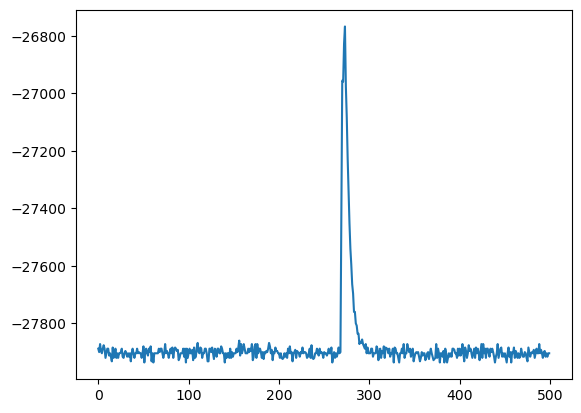

In [28]:
with h5py.File(dtg_file, "r") as h:
    raw = h["/light/wvfm/data"]["samples"][:N_EV, :, :, :500]

plt.plot(raw[156,3,5,:])

In [35]:
raw.argmax()

np.int64(215500)